In [300]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import os
import zipfile
import mlflow
import mlflow.xgboost
import xgboost as xgb

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore")
np.random.seed(42)

In [301]:
!pip install dagshub --upgrade

In [302]:
!pip install -q pandas numpy scikit-learn xgboost mlflow joblib kaggle

In [303]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [304]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [305]:
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting

walmart-recruiting-store-sales-forecasting.zip: Skipping, found more recently modified local copy (use --force to force download)


In [306]:
!mkdir -p data
!unzip walmart-recruiting-store-sales-forecasting.zip -d data/

Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: data/features.csv.zip   
  inflating: data/sampleSubmission.csv.zip  
replace data/stores.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: data/stores.csv         
  inflating: data/test.csv.zip       
  inflating: data/train.csv.zip      


In [307]:
import os
print(os.listdir("data"))

['features.csv.zip', 'train.csv', 'test.csv', 'sampleSubmission.csv.zip', 'features.csv', 'sampleSubmission.csv', 'train.csv.zip', 'test.csv.zip', 'stores.csv']


In [308]:
import os
import zipfile

data_dir = "data"
for file in os.listdir(data_dir):
    if file.endswith(".zip"):
        file_path = os.path.join(data_dir, file)
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print(f"Unzipped {file}")

print("Updated contents of data directory:", os.listdir(data_dir))

Unzipped features.csv.zip
Unzipped sampleSubmission.csv.zip
Unzipped train.csv.zip
Unzipped test.csv.zip
Updated contents of data directory: ['features.csv.zip', 'train.csv', 'test.csv', 'sampleSubmission.csv.zip', 'features.csv', 'sampleSubmission.csv', 'train.csv.zip', 'test.csv.zip', 'stores.csv']


In [309]:
train = pd.read_csv("data/train.csv")
stores = pd.read_csv("data/stores.csv")
features = pd.read_csv("data/features.csv")
test = pd.read_csv("data/test.csv")

print("Train shape:", train.shape)
print("Stores shape:", stores.shape)
print("Features shape:", features.shape)
print("Test shape:", test.shape)


Train shape: (421570, 5)
Stores shape: (45, 3)
Features shape: (8190, 12)
Test shape: (115064, 4)


In [310]:
print("\nTrain head:\n", train.head())
print("\nStores head:\n", stores.head())
print("\nFeatures head:\n", features.head())
print("\nTest head:\n", test.head())


Train head:
    Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False

Stores head:
    Store Type    Size
0      1    A  151315
1      2    A  202307
2      3    B   37392
3      4    A  205863
4      5    B   34875

Features head:
    Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548        NaN        NaN   
2      1  2010-02-19        39.93       2.514        NaN        NaN   
3      1  2010-02-26        46.63       2.561        NaN        NaN   
4      1  2010-03-05        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        

In [311]:
!rm data/*.zip
print("Remaining files:", os.listdir("data"))

Remaining files: ['train.csv', 'test.csv', 'features.csv', 'sampleSubmission.csv', 'stores.csv']


In [312]:
train = train.merge(stores, on="Store").merge(features, on=["Store", "Date"])
test = test.merge(stores, on="Store").merge(features, on=["Store", "Date"])
train["IsHoliday_x"] = train["IsHoliday_x"].astype(int)
test["IsHoliday_x"] = test["IsHoliday_x"].astype(int)
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])
train = train.sort_values(["Date", "Store", "Dept"])
test = test.sort_values(["Date", "Store", "Dept"])

In [313]:
def add_time_series_features(df):
    df = df.copy()
    df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
    df["Month"] = df["Date"].dt.month
    df["Year"] = df["Date"].dt.year
    df["Quarter"] = df["Date"].dt.quarter
    df["DayOfYear"] = df["Date"].dt.dayofyear
    df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)
    df["Week_sin"] = np.sin(2 * np.pi * df["Week"] / 52)
    df["Week_cos"] = np.cos(2 * np.pi * df["Week"] / 52)
    df["Store_Dept"] = df["Store"].astype(str) + "_" + df["Dept"].astype(str)
    return df

train = add_time_series_features(train)
test = add_time_series_features(test)

In [314]:
for col in ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

In [315]:
def add_lag_rolling_features(df):
    for lag in [1, 2, 3, 4, 8, 12]:
        df[f"Lag_{lag}"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(lag)
    for window in [4, 8, 12, 26]:
        df[f"Rolling_Mean_{window}"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1).rolling(window=window).mean()
        df[f"Rolling_Std_{window}"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1).rolling(window=window).std()
    for alpha in [0.1, 0.3, 0.5]:
        df[f"EMA_{alpha}"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1).ewm(alpha=alpha).mean()
    return df

train = add_lag_rolling_features(train)

In [316]:
train["Fuel_Price_Change"] = train.groupby("Store")["Fuel_Price"].pct_change()
train["CPI_Change"] = train.groupby("Store")["CPI"].pct_change()
train["Unemployment_Change"] = train.groupby("Store")["Unemployment"].pct_change()

store_stats = train.groupby(["Store", "Date"])["Weekly_Sales"].agg(['sum', 'mean', 'count']).reset_index()
store_stats.columns = ["Store", "Date", "Store_Total_Sales", "Store_Avg_Sales", "Store_Sales_Count"]
train = train.merge(store_stats, on=["Store", "Date"], how="left")

dept_stats = train.groupby(["Dept", "Date"])["Weekly_Sales"].agg(['sum', 'mean']).reset_index()
dept_stats.columns = ["Dept", "Date", "Dept_Total_Sales", "Dept_Avg_Sales"]

train = train.merge(dept_stats, on=["Dept", "Date"], how="left")

In [317]:
target = "Weekly_Sales"
binary_features = ["IsHoliday_x"]
numeric_features = [
    "Size", "Temperature", "Fuel_Price", "CPI", "Unemployment", "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "Lag_1", "Lag_2", "Lag_3", "Lag_4", "Rolling_Mean_4", "Rolling_Std_4", "EMA_0.3", "Fuel_Price_Change",
    "CPI_Change", "Unemployment_Change", "Store_Total_Sales", "Dept_Total_Sales"
]
categorical_features = ["Store", "Dept", "Type", "Week", "Month", "Year"]


In [318]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("bin", binary_transformer, binary_features)
])

In [319]:
def wmae(y_true, y_pred, holiday):
    weights = np.where(holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

train_clean = train[numeric_features + categorical_features + binary_features + [target]].dropna()
X = train_clean[numeric_features + categorical_features + binary_features]
y = train_clean[target]
is_holiday = train_clean["IsHoliday_x"]

xgb_params = {
    'objective': 'reg:squarederror',
    'random_state': 42
}
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", xgb.XGBRegressor(**xgb_params))
])

In [320]:
mlflow.set_experiment("XGBoost_Training")
wmae_scores = []

In [322]:
mlflow.end_run()
with mlflow.start_run(run_name="XGBoost_Baseline"):
    for fold, (train_idx, val_idx) in enumerate(TimeSeriesSplit(n_splits=5).split(X)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        h_val = is_holiday.iloc[val_idx]

        xgb_pipeline.fit(X_train, y_train)
        y_pred = xgb_pipeline.predict(X_val)
        score = wmae(y_val, y_pred, h_val)
        wmae_scores.append(score)

        mlflow.log_metric(f"fold_{fold+1}_wmae", score)

    avg_score = np.mean(wmae_scores)
    mlflow.log_metric("avg_wmae", avg_score)
    joblib.dump(xgb_pipeline, "models/xgb_pipeline.pkl")
    mlflow.log_artifact("models/xgb_pipeline.pkl")

print(f"Average WMAE: {avg_score:.3f}")


Average WMAE: 1935.836


In [325]:
xgb_pipeline = joblib.load("models/xgb_pipeline.pkl")
test["IsHoliday_x"] = test["IsHoliday_x"].astype(int)

last_sales = train.groupby(["Store", "Dept"])["Weekly_Sales"].last()
test["Lag_1"] = test.apply(lambda row: last_sales.get((row["Store"], row["Dept"]), 0), axis=1)
test["Lag_2"] = test["Lag_1"]  # approximate
test["Rolling_Mean_4"] = test["Lag_1"]  # approximate

In [326]:
numeric_features = ["Size", "Temperature", "Fuel_Price", "CPI", "Unemployment",
                    "Lag_1", "Lag_2", "Rolling_Mean_4", "MarkDown1", "MarkDown2",
                    "MarkDown3", "MarkDown4", "MarkDown5"]
categorical_features = ["Store", "Dept", "Type", "Week", "Month", "Year"]
binary_features = ["IsHoliday_x"]

In [334]:
X_test = test[numeric_features + categorical_features + binary_features].fillna(0)
train["IsHoliday_x"] = train["IsHoliday_x"].astype(int)
test["IsHoliday_x"] = test["IsHoliday_x"].astype(int)

In [335]:
print(train["Weekly_Sales"])

0         24924.50
1         50605.27
2         13740.12
3         39954.04
4         32229.38
            ...   
421565     2487.80
421566     5203.31
421567    56017.47
421568     6817.48
421569     1076.80
Name: Weekly_Sales, Length: 421570, dtype: float64


In [336]:
def add_all_features(df):
    df = df.copy()
    # Time features
    df["Week"] = df["Date"].dt.isocalendar().week
    df["Month"] = df["Date"].dt.month
    df["Year"] = df["Date"].dt.year
    df["Quarter"] = df["Date"].dt.quarter
    df["DayOfYear"] = df["Date"].dt.dayofyear
    df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)
    df["Week_sin"] = np.sin(2 * np.pi * df["Week"] / 52)
    df["Week_cos"] = np.cos(2 * np.pi * df["Week"] / 52)

    # Lags & rolling windows by Store & Dept
    for lag in [1, 2, 3, 4, 8, 12]:
        df[f"Lag_{lag}"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(lag)

    for window in [4, 8, 12, 26]:
        df[f"Rolling_Mean_{window}"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1).rolling(window=window).mean()
        df[f"Rolling_Std_{window}"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1).rolling(window=window).std()

    # EMAs
    for alpha in [0.1, 0.3, 0.5]:
        df[f"EMA_{alpha}"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1).ewm(alpha=alpha).mean()

    # Store-level stats per Date
    store_stats = df.groupby(["Store", "Date"])["Weekly_Sales"].agg(['sum', 'mean', 'count']).reset_index()
    store_stats.columns = ["Store", "Date", "Store_Total_Sales", "Store_Avg_Sales", "Store_Sales_Count"]
    df = df.merge(store_stats, on=["Store", "Date"], how="left")

    # Dept-level stats per Date
    dept_stats = df.groupby(["Dept", "Date"])["Weekly_Sales"].agg(['sum', 'mean']).reset_index()
    dept_stats.columns = ["Dept", "Date", "Dept_Total_Sales", "Dept_Avg_Sales"]
    df = df.merge(dept_stats, on=["Dept", "Date"], how="left")

    # Percent changes by Store
    df["Fuel_Price_Change"] = df.groupby("Store")["Fuel_Price"].pct_change()
    df["CPI_Change"] = df.groupby("Store")["CPI"].pct_change()
    df["Unemployment_Change"] = df.groupby("Store")["Unemployment"].pct_change()

    # Rolling means of external features
    df["Fuel_Price_MA_4"] = df.groupby("Store")["Fuel_Price"].rolling(4).mean().reset_index(0, drop=True)
    df["Temperature_MA_4"] = df.groupby("Store")["Temperature"].rolling(4).mean().reset_index(0, drop=True)

    # Sales trend (slope)
    df["Sales_Trend_4"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1).rolling(4).apply(
        lambda x: np.polyfit(range(len(x)), x, 1)[0] if len(x) == 4 else np.nan
    ).reset_index(0, drop=True)

    # Composite feature for Store+Dept
    df["Store_Dept"] = df["Store"].astype(str) + "_" + df["Dept"].astype(str)

    return df

In [340]:
train["is_train"] = True
test["Weekly_Sales"] = np.nan
test["is_train"] = False


combined = pd.concat([train, test], ignore_index=True, sort=False)
combined = add_all_features(combined)
train_enhanced = combined[combined["is_train"]].copy()
test_enhanced = combined[~combined["is_train"]].copy()

train_enhanced.drop(columns=["is_train"], inplace=True)
test_enhanced.drop(columns=["is_train", "Weekly_Sales"], inplace=True)

for md in ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]:
    if md in test_enhanced.columns:
        test_enhanced[md] = test_enhanced[md].fillna(0)

In [344]:
for col in ["Dept_Total_Sales", "Store_Total_Sales"]:
    if col not in test_enhanced.columns:
        test_enhanced[col] = 0

# Just in case, fill NAs in these columns as well
test_enhanced["Dept_Total_Sales"] = test_enhanced["Dept_Total_Sales"].fillna(0)
test_enhanced["Store_Total_Sales"] = test_enhanced["Store_Total_Sales"].fillna(0)

In [349]:
final_features = [
    "Size", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Lag_1", "Lag_2", "Lag_3", "Lag_4",
    "Rolling_Mean_4", "Rolling_Mean_8", "Rolling_Mean_12", "Rolling_Mean_26",
    "Rolling_Std_4", "Rolling_Std_8", "Rolling_Std_12", "Rolling_Std_26",
    "EMA_0.1", "EMA_0.3", "EMA_0.5",
    "Fuel_Price_Change", "CPI_Change", "Unemployment_Change",
    "Fuel_Price_MA_4", "Temperature_MA_4", "Sales_Trend_4",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "Week", "Month", "Year", "Quarter", "DayOfYear",
    "Month_sin", "Month_cos", "Week_sin", "Week_cos",
    "Store", "Dept", "Type", "Store_Dept", "IsHoliday_x",
    "Dept_Total_Sales", "Store_Total_Sales"
]


def ensure_columns(df, columns):
    for col in columns:
        if col not in df.columns:
            print(f"Adding missing column: {col} with zeros")
            df[col] = 0
    return df

test_enhanced = ensure_columns(test_enhanced, final_features)
X_test = test_enhanced[final_features].fillna(0)
test_preds = xgb_pipeline.predict(X_test)


In [350]:
submission = pd.DataFrame({
    "Id": test_enhanced["Store"].astype(str) + "_" + test_enhanced["Dept"].astype(str) + "_" + test_enhanced["Date"].dt.strftime('%Y-%m-%d'),
    "Weekly_Sales": test_preds
})
submission.to_csv("submission.csv", index=False)
print("Submission file saved as submission.csv")

Submission file saved as submission.csv


In [351]:
mlflow.log_artifact("submission.csv", artifact_path="submissions")
joblib.dump(xgb_pipeline, "models/xgb_pipeline_final.pkl")
mlflow.log_artifact("models/xgb_pipeline_final.pkl", artifact_path="models")

In [352]:
import matplotlib.pyplot as plt
import xgboost as xgb

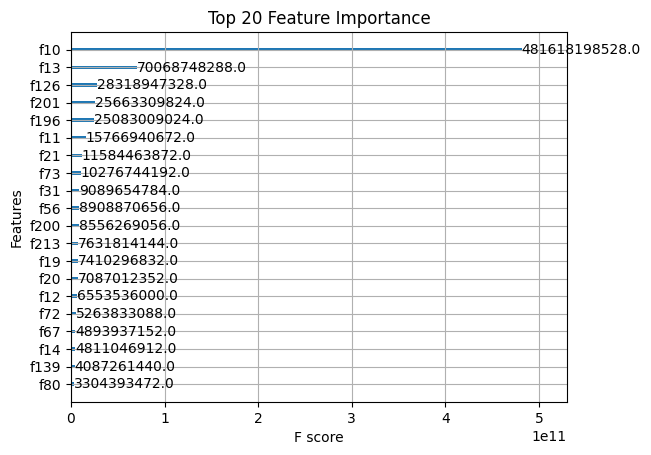

In [353]:
model = xgb_pipeline.named_steps["regressor"]
xgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.title("Top 20 Feature Importance")
plt.show()

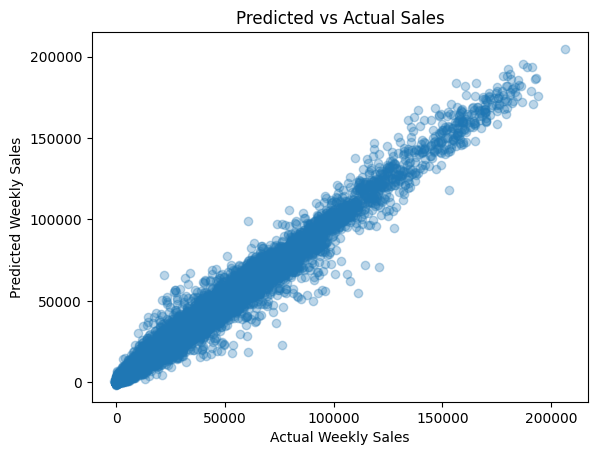

In [354]:
plt.scatter(y_val, y_pred, alpha=0.3)
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Predicted vs Actual Sales")
plt.show()

In [355]:
print(f"Average WMAE: {avg_score:.3f}")

Average WMAE: 1935.836


In [360]:
run = mlflow.active_run()
print(f"MLflow Run ID: {run.info.run_id}")
print(f"Experiment ID: {run.info.experiment_id}")
print(f"Run URL: {mlflow.get_tracking_uri()}/#/experiments/{run.info.experiment_id}/runs/{run.info.run_id}")

MLflow Run ID: cd66240ca6be4d3e87ea5c8a6e7ebffa
Experiment ID: 335806621877873386
Run URL: file:///content/mlruns/#/experiments/335806621877873386/runs/cd66240ca6be4d3e87ea5c8a6e7ebffa
